In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)



In [4]:
graph_builder

In [11]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x10c326a50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10c327770>, model_name='compound', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
def chatBot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder.add_node("llmchatbot",chatBot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

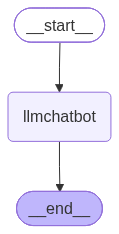

In [12]:
graph

In [14]:
res = graph.invoke({"messages":"Hi"})

In [19]:
res['messages'][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [22]:
res1 = graph.invoke({"messages":"help me learn langgraph"})

In [25]:
res1['messages'][-1].content

'LangGraph is a powerful tool for building and querying knowledge graphs. Here\'s a beginner\'s guide to help you get started:\n\n**What is LangGraph?**\nLangGraph is an open-source library for building, querying, and reasoning over knowledge graphs. It\'s designed to work with large-scale datasets and provides a flexible and scalable framework for knowledge representation and reasoning.\n\n**Key Concepts**\n\n1. **Entities**: Represented as nodes in the graph, entities can be objects, concepts, or individuals.\n2. **Relations**: Represented as edges in the graph, relations describe the connections between entities.\n3. **Graph**: A collection of entities and relations that form a network of knowledge.\n4. **Queries**: Used to retrieve specific information from the graph, queries can be simple or complex, depending on the use case.\n\n**Basic Components of LangGraph**\n\n1. **Node**: Represents an entity in the graph, with attributes such as labels, properties, and relationships.\n2. *

In [27]:
for event in graph.stream({"messages":"Hi! How are you? "}):
    for val in event.values():
        print(val['messages'][-1])

content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 42, 'total_tokens': 89, 'completion_time': 0.132596134, 'completion_tokens_details': None, 'prompt_time': 0.001975055, 'prompt_tokens_details': None, 'queue_time': 0.161358643, 'total_time': 0.134571189}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f90b6-bcb2-7371-b9cd-8d412cc63fbe-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 42, 'output_tokens': 47, 'total_tokens': 89}
